In [481]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as ms

In [487]:
ds1 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/CMEMS/cmems_new/CMEMS_ph_mask.nc')
ds2 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/SODA/SODA_new/SODA_ph_mask.nc')
# ens = xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/pH_ensemble_ssp585_merged.nc')



ens = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/pH_ensemble_ssp126_merged_r1.nc')


# ds4 = xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_ens_ssp585_biascorrected.nc') 
# ds5 = xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_ens_ssp585_biascorrected_mean.nc') 
ds3 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/REF_pH_v2.nc')
obs = xr.open_dataset('/media/athira/One Touch/final_datasets/Takahashi_clim_mask.nc')
# ds8 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Takahashi_GLOB_Grid_Dat.nc').ph


ds4= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_canesm_hist_mask.nc')
ds5= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_cesm2_hist_mask.nc')

ds6= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CESM2/ph_CESM2_historical_mask.nc')
ds7= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CMCC/ph_CMCC_historical_mask.nc')
ds8= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_gfdl-esm4_hist_mask.nc')
ds9= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/IPSL/ph_IPSL_historical_mask.nc')
ds10= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_mpi-esm-hr_hist_mask.nc')
ds11= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_noresm-mm_hist_mask.nc')
ds12= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_noresm-lm_hist_mask.nc')

# ds3 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/regrid_recon_ph_1deg.nc')
lat_range = slice(-30, 30)
lon_range = slice(30, 120)
# lat_range = slice(5, 27) 
# lon_range = slice(50, 100) 

# subset_ds1 = ds1.sel(lat=lat_range, lon=lon_range)#.groupby('time.month').mean()
# subset_ds2 = ds2.sel(lat=lat_range, lon=lon_range)#.groupby('time.month').mean()


In [488]:
# ds3

In [489]:
subset_ds1 = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds2 = ds2.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()

# subset_ds1['time'] = subset_ds1.indexes['time'].to_period('M').to_timestamp()
# subset_ds2['time'] = subset_ds2.indexes['time'].to_period('M').to_timestamp()

# # Interpolate ds2 onto ds1 grid (lat, lon, time)
# subset_ds2_interp = subset_ds2.interp(
#     lat=subset_ds1['lat'],
#     lon=subset_ds1['lon'],
#     time=subset_ds1['time'],
#     method='linear'
# )

# # Calculate mean pH
# ph_mean = xr.concat(
#     [subset_ds1['ph'], subset_ds2_interp['ph']],
#     dim='model'
# ).mean(dim='model')

subset_ds3_sub = ds3.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds4_sub = ds4.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds5_sub = ds5.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds6_sub = ds6.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds7_sub = ds7.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds8_sub = ds8.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds9_sub = ds9.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds10_sub = ds10.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds11_sub = ds11.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds12_sub = ds12.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
obs = obs.sel(lat=lat_range, lon=lon_range)


ens_sub = ens.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
# obs_sub = ph_mean.sel(lat=lat_range, lon=lon_range, time=slice('1993', '2014')).groupby('time.month').mean()
# subset_ds1['time'] = subset_ds1_sub.indexes['time'].to_period('M').to_timestamp()
# subset_ds2['time'] = subset_ds2_sub.indexes['time'].to_period('M').to_timestamp()
obs = obs.rename_dims({
    "time": "month",
})

# ds3 = ds3.rename_dims({
#     "Time": "time",
#     "Lat": "lat",
#     "Lon": "lon"
# })

# # Rename coordinates (important!)
# ds3 = ds3.rename_vars({
#     "Time": "time",
#     "Lat": "lat",
#     "Lon": "lon",
#     "pH": "ph"
# })
# ds3_sub = ds3.sel(lat=lat_range, lon=lon_range, time=slice('1993', '2014')).groupby('time.month').mean()


In [490]:
#subset_ds2_sub#ds8.ph#.isel(time=0).ph.plot()

In [640]:
# lat_tgt = subset_ds8_sub.lat
# lon_tgt = subset_ds8_sub.lon
lat_tgt = subset_ds2.lat
lon_tgt = subset_ds2.lon

In [641]:
ph_mod_rg = subset_ds12_sub.interp(
    lat=lat_tgt,
    lon=lon_tgt,
    method="linear"
)


In [642]:
ens_sub

<xarray.Dataset> Size: 534kB
Dimensions:   (month: 12, lat: 61, lon: 91)
Coordinates:
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 364B 30.12 31.12 32.12 33.12 ... 118.1 119.1 119.9
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    method    <U7 28B 'nearest'
    olevel    float32 4B 0.5058
Data variables:
    ph        (month, lat, lon) float64 533kB nan nan nan 8.077 ... nan nan nan

In [643]:
# ph_obs_mon = ds3_sub.assign_coords(
#     month=ds3_sub.time.dt.month
# ).swap_dims({"time": "month"}).drop("time")


In [644]:
ph_mod = subset_ds12_sub.ph.sel(lev=ph_mod_rg.lev.values[0])  



In [645]:
ph_mod = ph_mod.transpose('month', 'lat', 'lon')
ph_obs = subset_ds2.transpose('month', 'lat', 'lon')


In [646]:
ph_obs

<xarray.Dataset> Size: 534kB
Dimensions:   (month: 12, lat: 61, lon: 91)
Coordinates:
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 364B 30.12 30.62 31.62 32.62 ... 117.6 118.6 119.6
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
Data variables:
    ph        (month, lat, lon) float64 533kB nan nan 8.087 ... nan nan nan

In [647]:
# Extract the pH DataArray from both datasets
# ph_mod = ph_mod['ph']
ph_obs = ph_obs['ph']

print("Original model shape:", ph_mod.shape)
print("Observation shape:", ph_obs.shape)

# Regrid/interpolate model onto the observation grid
ph_mod_regrid = ph_mod.interp(
    lat=ph_obs.lat,
    lon=ph_obs.lon,
    method='nearest'
)

# Check dimensions after regridding
print("Regridded model shape:", ph_mod_regrid.shape)
print("Observation shape:", ph_obs.shape)

# Create NaN masks
mask_mod = np.isnan(ph_mod_regrid)
mask_obs = np.isnan(ph_obs)

# Common mask:
# A grid point is masked if either model OR observation is NaN
common_mask = mask_mod | mask_obs

# Apply the same mask to both datasets
ph_mod_common = ph_mod_regrid.where(~common_mask)
ph_obs_common = ph_obs.where(~common_mask)

# Final check
mask1_new = np.isnan(ph_mod_common)
mask2_new = np.isnan(ph_obs_common)

print("Model final shape:", ph_mod_common.shape)
print("Observation final shape:", ph_obs_common.shape)

print("Identical masks:", np.array_equal(mask1_new, mask2_new))

print("Model NaNs:", mask1_new.sum().item())
print("Observation NaNs:", mask2_new.sum().item())

Original model shape: (12, 61, 90)
Observation shape: (12, 61, 91)
Regridded model shape: (12, 61, 91)
Observation shape: (12, 61, 91)
Model final shape: (12, 61, 91)
Observation final shape: (12, 61, 91)
Identical masks: True
Model NaNs: 29352
Observation NaNs: 29352


In [648]:
# print(ph_obs_final.shape)
# print(ph_mod_final.shape)

# print(np.isnan(ph_obs_final).sum().item(),
#       np.isnan(ph_mod_final).sum().item())
# mask1 = np.isnan(ph_mod_final.ph)
# mask2 = np.isnan(ph_obs_final.ph)

# same_nan_mask = np.array_equal(mask1, mask2)

# print("NaN masks identical:", same_nan_mask)
# print("NaNs in ds1:", mask1.sum().item())
# print("NaNs in ds2:", mask2.sum().item())
# mask1_new = np.isnan(ph_mod_common)
# mask2_new = np.isnan(ph_obs_common)

# print(np.array_equal(mask1_new, mask2_new))
# print(mask1_new.sum().item(), mask2_new.sum().item())


In [649]:
def will_skill_nan(ref, mod):
    # Mask NaNs
    valid_mask = ~np.isnan(ref) & ~np.isnan(mod)
    ref_valid = ref[valid_mask]
    mod_valid = mod[valid_mask]

    # Proceed only if there are enough valid values
    if len(ref_valid) == 0 or len(mod_valid) == 0:
        return np.nan  # Return NaN if no valid values
    
    mse = ms(ref_valid, mod_valid)
    kk = np.nanmean((np.abs(mod_valid - np.nanmean(ref_valid)) + np.abs(ref_valid - np.nanmean(ref_valid))) ** 2)
    ws1 = mse / kk
    ws = 1 - ws1
    return ws

# Wrapper for xarray apply_ufunc with NaN handling
def calculate_skill_score_nan(ref_ds, mod_ds):
    # Apply skill score calculation spatially
    skill = xr.apply_ufunc(
        will_skill_nan,  # Function to apply
        ref_ds,          # Reference data (obs)
        mod_ds,          # Model data
        input_core_dims=[['month'], ['month']],  # Dimensions over which to apply
        vectorize=True,  # Vectorize for broadcasting
        dask="parallelized",  # Enable Dask for larger datasets
        output_dtypes=[float],  # Output dtype
    )
    return skill

In [650]:
skill_cmems = calculate_skill_score_nan(ph_obs_common, ph_mod_common)

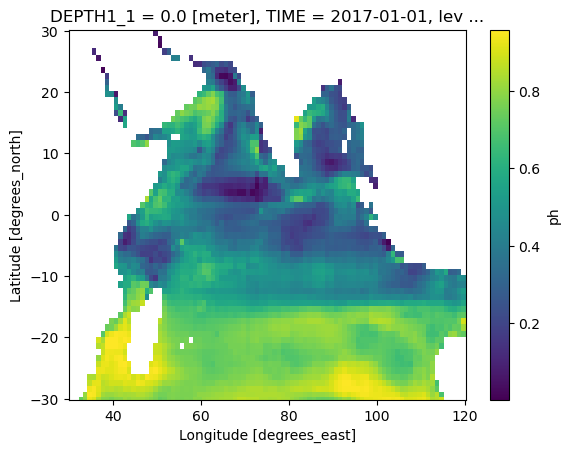

In [651]:
skill_cmems.plot()

In [652]:
lat_range_as = slice(0, 30)
lon_range_as = slice(38, 78)

skill_bias_as = skill_cmems.sel(lat=lat_range_as, lon=lon_range_as).mean()
skill_bias_as

<xarray.DataArray 'ph' ()> Size: 8B
array(0.39625892)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 0.0

In [653]:
lat_range_bob = slice(0, 30)
lon_range_bob = slice(78, 120)

skill_bias_bob = skill_cmems.sel(lat=lat_range_bob, lon=lon_range_bob).mean()
skill_bias_bob

<xarray.DataArray 'ph' ()> Size: 8B
array(0.36301494)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 0.0

In [654]:
# round(0.71512, 2)

In [655]:
lat_range_cio = slice(-18, 0)
lon_range_cio = slice(30, 120)

skill_bias_cio = skill_cmems.sel(lat=lat_range_cio, lon=lon_range_cio).mean()
skill_bias_cio

<xarray.DataArray 'ph' ()> Size: 8B
array(0.47504441)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 0.0

In [656]:
lat_range_sio = slice(-30, -18)
lon_range_sio = slice(30, 120)

skill_bias_sio = skill_cmems.sel(lat=lat_range_sio, lon=lon_range_sio).mean()
skill_bias_sio

<xarray.DataArray 'ph' ()> Size: 8B
array(0.79875058)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 0.0